In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import torch
from PIL import Image
from diffusers import FluxControlNetPipeline, FluxControlNetModel, FluxPriorReduxPipeline, FluxFillPipeline
from diffusers.models import FluxMultiControlNetModel
from controlnet_aux import OpenposeDetector
from detector.groundingdino_sam import GroundingdinoSam
from utils import image_grid, down_size
from controlnet_aux import CannyDetector
import json
from utils import get_mask_ori
from matplotlib import pyplot as plt

/amax/hchuz/miniconda3/envs/py310/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


In [3]:
device = 'cuda'
dino_checkpoint = '/amax/hchuz/OMG-master/checkpoint/GroundingDINO'
sam_checkpoint = '/amax/hchuz/OMG-master/checkpoint/sam/sam_vit_h_4b8939.pth'
pipe_prior_redux = FluxPriorReduxPipeline.from_pretrained("black-forest-labs/FLUX.1-Redux-dev", torch_dtype=torch.bfloat16).to(device)
pipe = FluxFillPipeline.from_pretrained("/amax/hchuz/hfd_models/FLUX.1-Fill-dev", 
                                            torch_dtype=torch.bfloat16)
_ = pipe.to(device)
groundingdino_sam = GroundingdinoSam(dino_checkpoint, sam_checkpoint)

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

final text_encoder_type: bert-base-uncased


Model loaded from groundingdino_swinb_cogcoor.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [ ]:
# img1 = Image.open('/amax/hchuz/architectural_heritage/temp/window1.png').convert('RGB')
# img1

: 

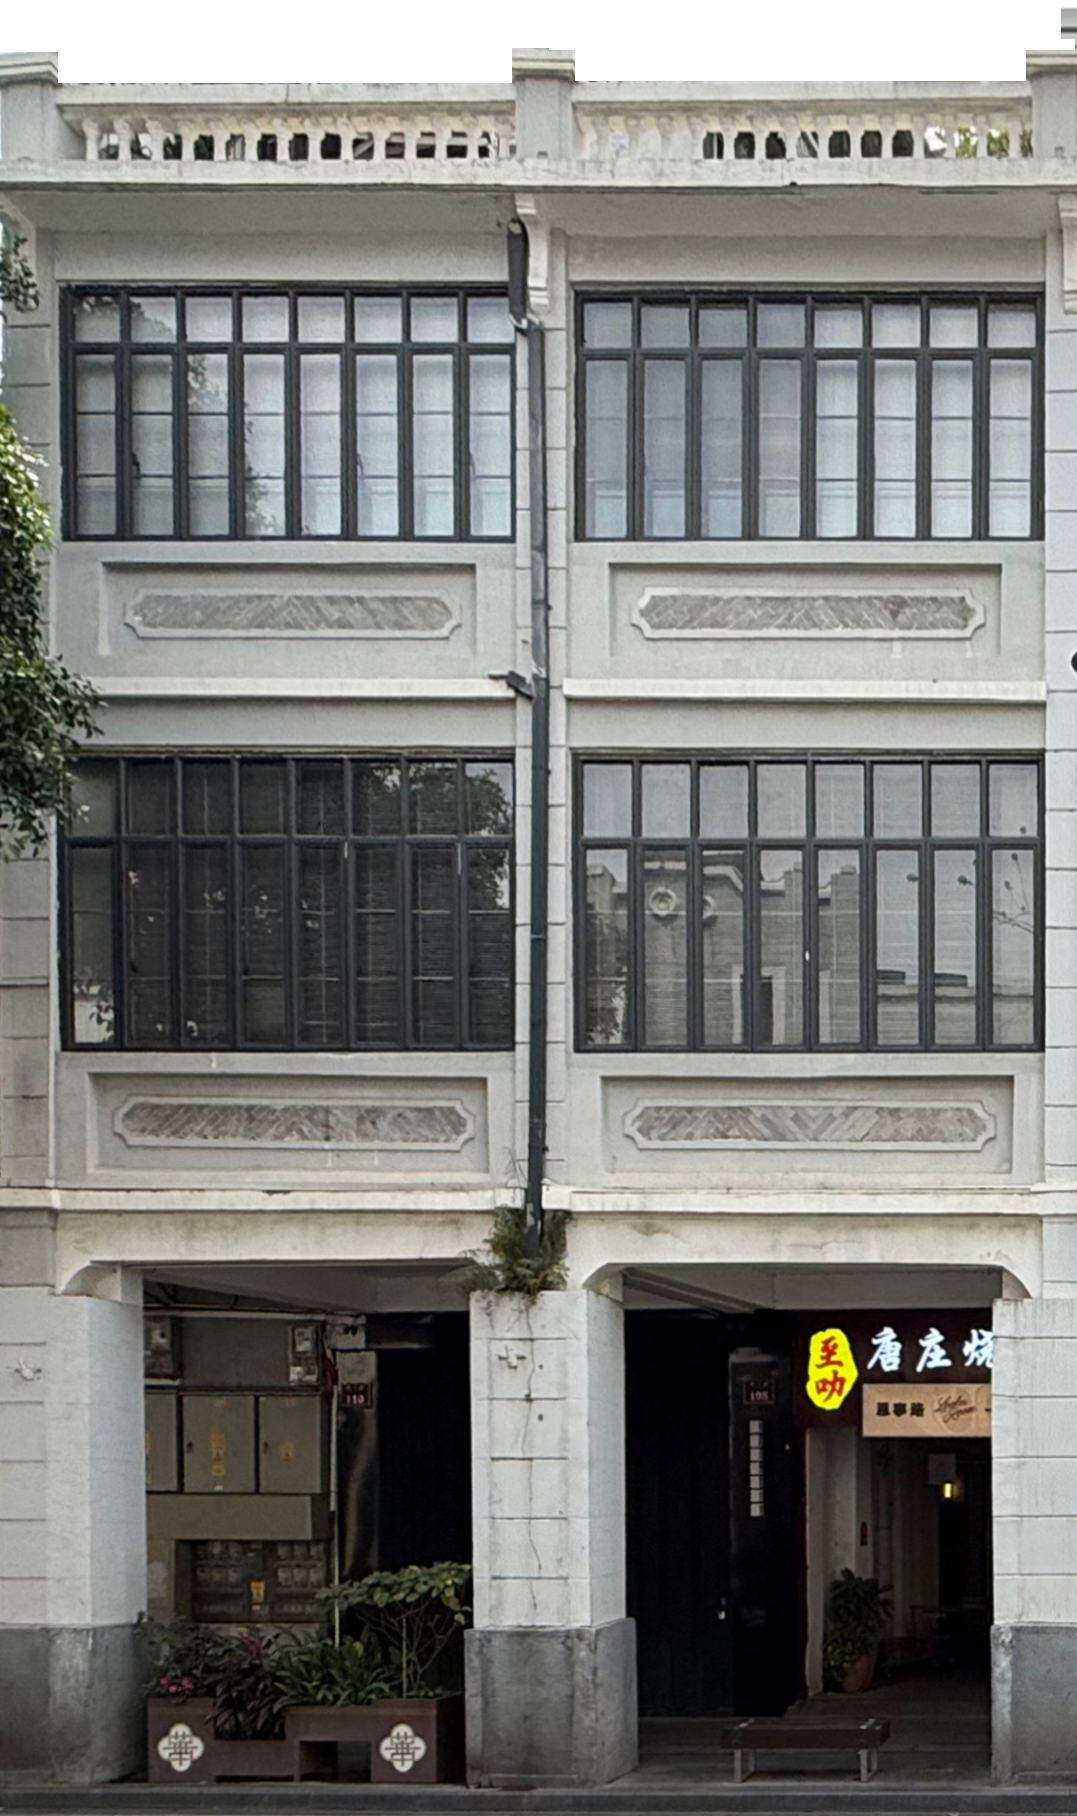

In [18]:
img2 = Image.open('/amax/hchuz/architectural_heritage/temp/window4.png').convert('RGB')
img2

In [54]:
# boxes = groundingdino_sam.pred_box_with_prompt(img1, 'window')
# ref_img = img1.crop(boxes[0])
# ref_img

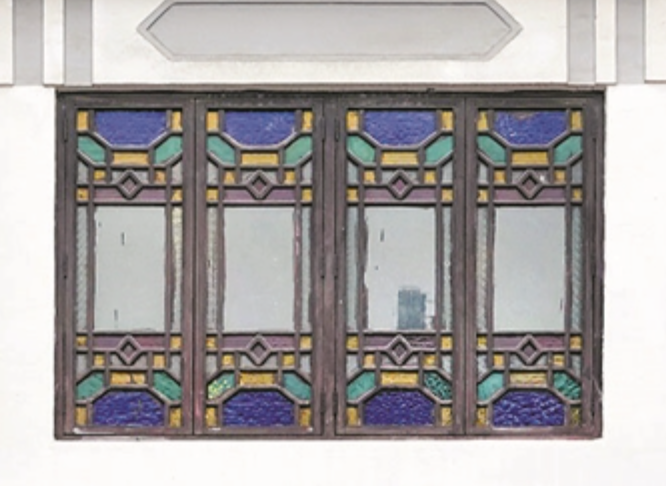

In [20]:
ref_img = Image.open('/amax/hchuz/architectural_heritage/temp/ref_window3.png').convert('RGB')
ref_img

In [21]:
boxes = groundingdino_sam.pred_box_with_prompt(img2, 'window')
mask = torch.zeros((img2.height, img2.width), dtype=torch.float)
for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    mask[y1:y2, x1:x2] = True

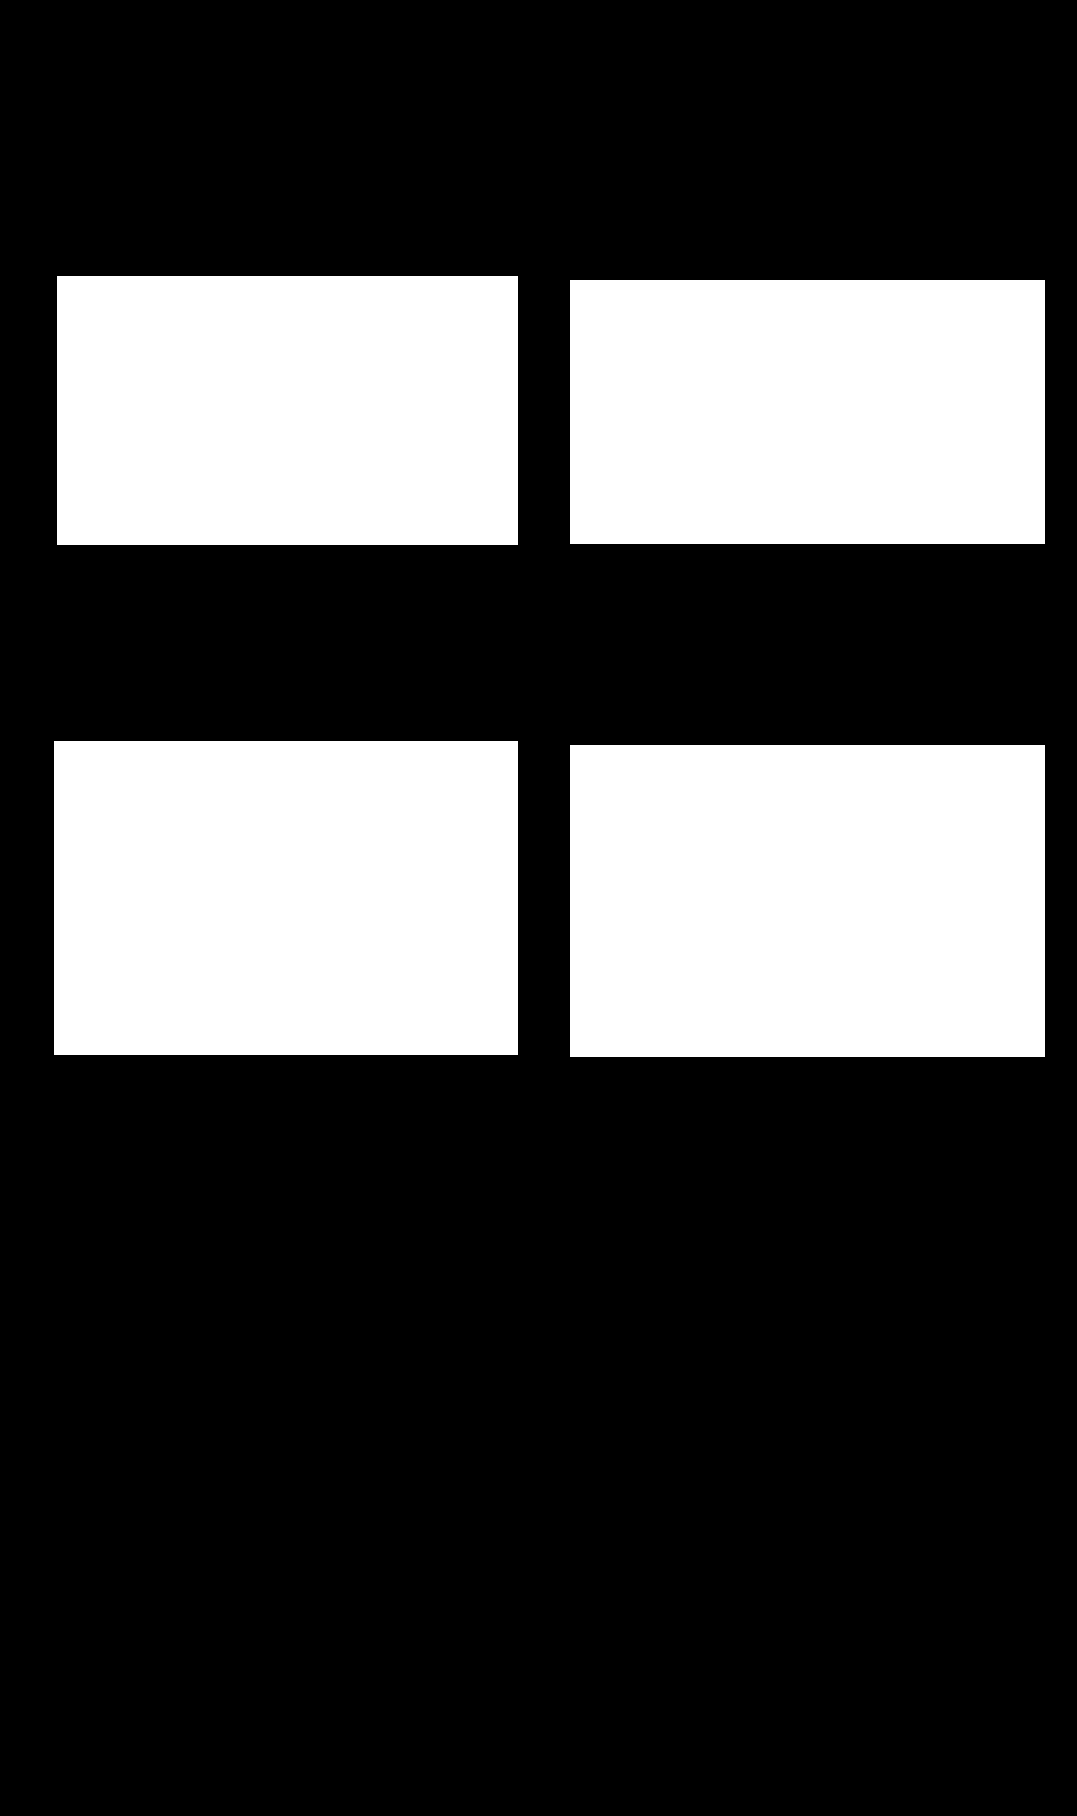

In [ ]:
Image.fromarray((mask.numpy()*255).astype('uint8'))

`height` and `width` have to be divisible by 16 but are 1816 and 1077. Dimensions will be resized accordingly


  0%|          | 0/20 [00:00<?, ?it/s]

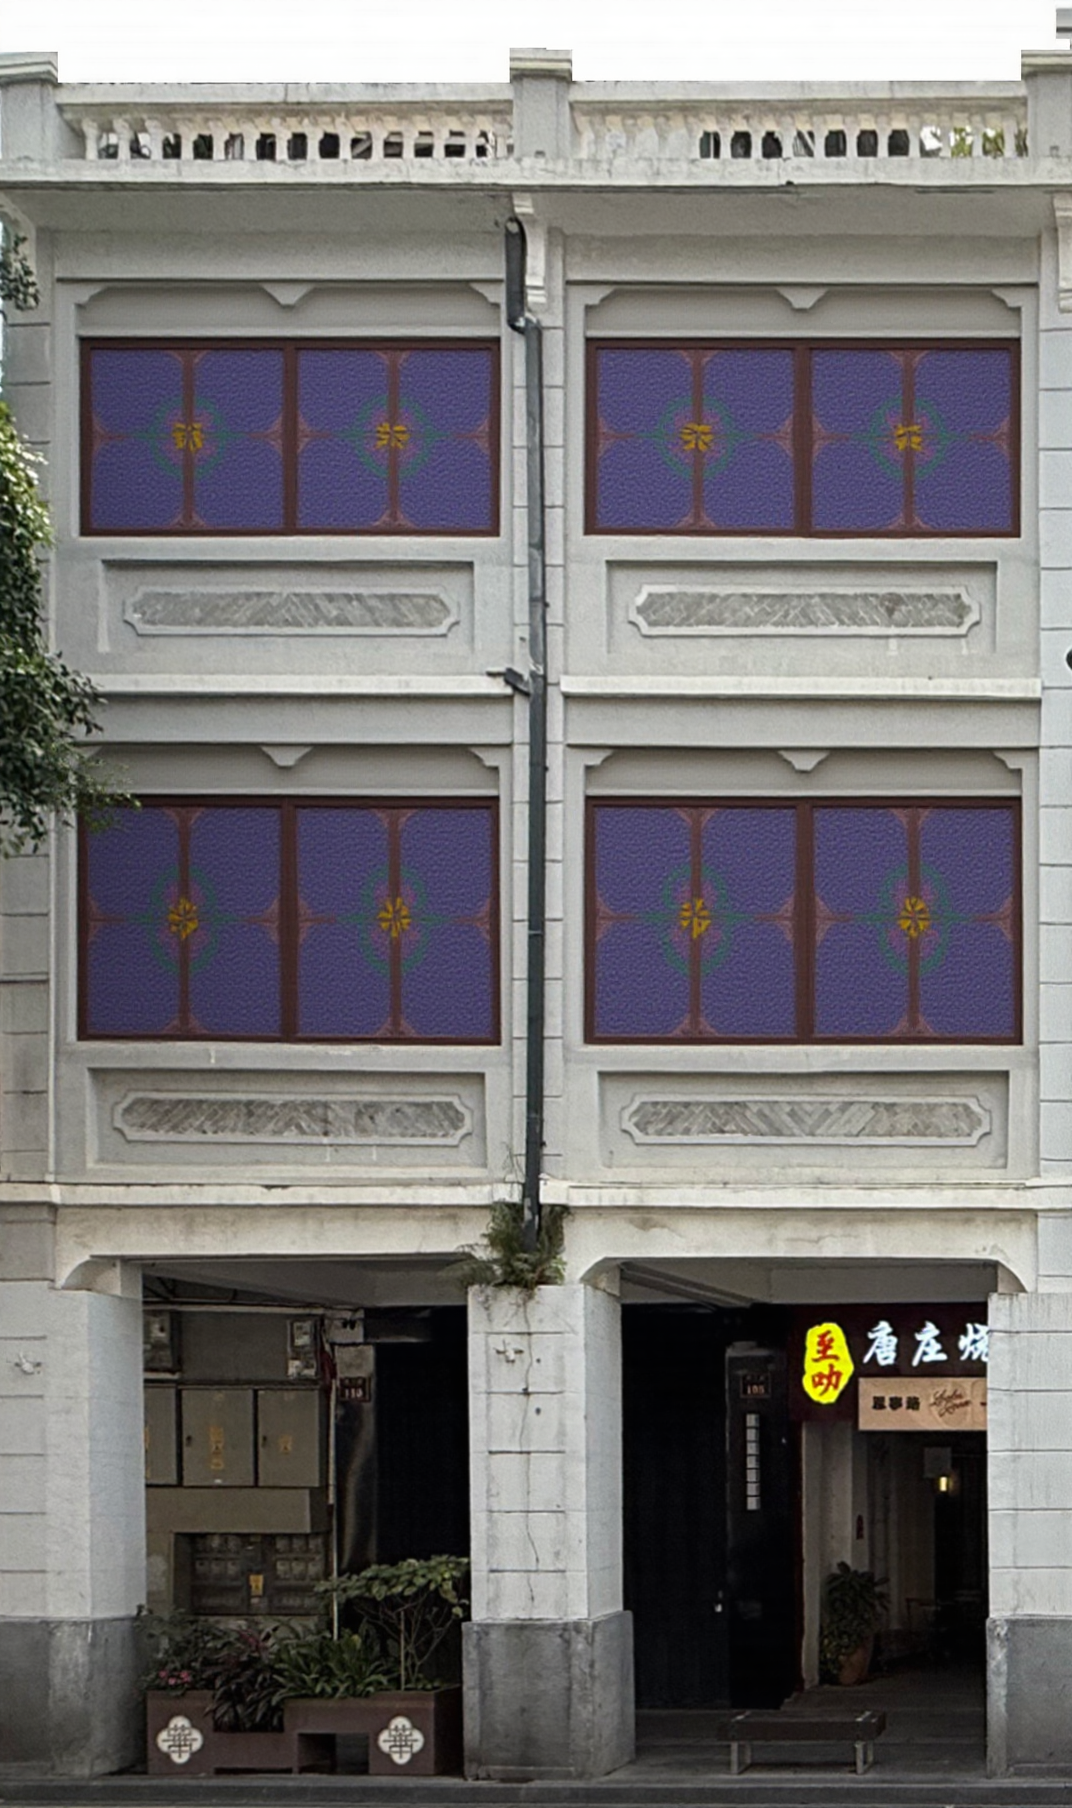

In [24]:
region_style_input = pipe_prior_redux(ref_img)
image2 = pipe(
    **region_style_input,
    image=img2,
    mask_image=mask.float(),
    height=img2.height,
    width=img2.width,
    guidance_scale=30,
    num_inference_steps=20,
    #generator=torch.Generator("cpu").manual_seed(seed),
).images[0]
image2